# Fase 5 - Modelo predictivo: ¿qué pedidos acabarán con mala valoración?

**Objetivo:** estimar, para cada pedido ya entregado, la probabilidad de que el cliente ponga 1 o 2 estrellas.

**Para qué sirve:** atención al cliente puede contactar con los pedidos de más riesgo antes de que valoren.

**Tipo de problema:** clasificación binaria (mala nota: sí o no).

Pasos:
1. Definir el objetivo y las variables.
2. Separar datos de entrenamiento y de prueba.
3. Entrenar dos modelos: regresión logística y random forest.
4. Medirlos con las métricas adecuadas.
5. Ver qué variables pesan más y qué uso tiene en el negocio.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pedidos = pd.read_csv("../data/clean/pedidos.csv",
                      parse_dates=["order_purchase_timestamp", "order_estimated_delivery_date"])

AZUL, NARANJA = "#3b6ea5", "#d9822b"

## 1. Objetivo y variables

**Objetivo (`y`)**: 1 si la valoración es de 1-2 estrellas, 0 si es de 3-5. Los pedidos sin valoración no sirven para entrenar.

In [2]:
datos = pedidos.dropna(subset=["review_score"]).copy()
datos["mala_nota"] = (datos["review_score"] <= 2).astype(int)

print(f"Pedidos con valoración: {len(datos):,}")
print(f"Con mala nota:          {datos['mala_nota'].mean():.1%}")

Pedidos con valoración: 95,560
Con mala nota:          12.8%


El objetivo está **desbalanceado**: solo 1 de cada 8 pedidos es "malo". Esto condiciona cómo se mide el modelo (apartado 4).

**Variables (`X`)**: solo información que se conoce en el momento de predecir, es decir, justo tras la entrega.

| Se conoce al comprar | Se conoce al entregar |
|---|---|
| valor, envío, nº de productos, nº de vendedores | días de entrega |
| cuotas, tipo de pago, categoría, estado | días respecto a la fecha estimada |
| plazo prometido | |

Usar algo que solo se sabe *después* (por ejemplo, el texto del comentario) sería **fuga de datos** (*data leakage*):
el modelo parecería muy bueno y no serviría para nada en la práctica.

In [3]:
datos["dias_prometidos"] = (datos["order_estimated_delivery_date"]
                            - datos["order_purchase_timestamp"]).dt.total_seconds() / 86400
datos["pct_envio"] = datos["valor_envio"] / datos["valor_total"]

# Categoría: nos quedamos con las 15 más frecuentes y agrupamos el resto en "otras"
top_categorias = datos["categoria_principal"].value_counts().head(15).index
datos["categoria"] = datos["categoria_principal"].where(datos["categoria_principal"].isin(top_categorias), "otras")

numericas_compra = ["valor_total", "valor_envio", "pct_envio", "n_items", "n_vendedores", "cuotas", "dias_prometidos"]
numericas_entrega = ["dias_entrega", "dias_vs_estimado"]
categoricas = ["categoria", "customer_state", "tipo_pago"]

# Los modelos solo entienden números: get_dummies convierte cada categoría en una columna de 0/1
X = pd.get_dummies(datos[numericas_compra + numericas_entrega + categoricas], columns=categoricas, dtype=int)
y = datos["mala_nota"]

X.shape

(95560, 56)

## 2. Entrenamiento y prueba

El modelo aprende con el 80 % de los pedidos y se evalúa con el 20 % restante, que no ha visto nunca.
`stratify=y` mantiene el mismo porcentaje de malas notas en las dos partes.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {len(X_train):,} pedidos, {y_train.mean():.1%} con mala nota")
print(f"Prueba:        {len(X_test):,} pedidos, {y_test.mean():.1%} con mala nota")

Entrenamiento: 76,448 pedidos, 12.8% con mala nota
Prueba:        19,112 pedidos, 12.8% con mala nota


## 3. Dos modelos

| Modelo | Idea | Ventaja | Inconveniente |
|---|---|---|---|
| Regresión logística | Suma ponderada de las variables | Simple y fácil de explicar | Solo capta relaciones lineales |
| Random forest | Cientos de árboles de decisión que votan | Capta relaciones complejas | Más difícil de explicar |

`class_weight="balanced"` hace que el modelo dé más importancia a las malas notas, que son pocas.

In [5]:
logistica = make_pipeline(StandardScaler(),
                          LogisticRegression(class_weight="balanced", max_iter=1000))
logistica.fit(X_train, y_train)

bosque = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, class_weight="balanced",
                                n_jobs=-1, random_state=42)
bosque.fit(X_train, y_train)

# Probabilidad de mala nota que da cada modelo a los pedidos de prueba
prob_log = logistica.predict_proba(X_test)[:, 1]
prob_rf = bosque.predict_proba(X_test)[:, 1]

## 4. ¿Cómo de buenos son?

### La trampa de la exactitud (*accuracy*)
Un "modelo" que dijera siempre "nota buena" acertaría el 87 % de las veces sin detectar ni un solo caso malo.
Por eso con datos desbalanceados se usan otras métricas:

| Métrica | Pregunta que responde |
|---|---|
| **Precisión** | De los que marco como malos, ¿cuántos lo son? |
| **Recall** (sensibilidad) | De los malos de verdad, ¿cuántos detecto? |
| **AUC** | ¿Ordena bien el modelo de más a menos riesgo? 0,5 = azar, 1 = perfecto |

In [6]:
def metricas(nombre, prob, umbral=0.5):
    pred = (prob >= umbral).astype(int)
    return {"modelo": nombre,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "AUC": roc_auc_score(y_test, prob)}

comparacion = pd.DataFrame([
    metricas("Siempre 'nota buena'", np.zeros(len(y_test))),
    metricas("Regresión logística", prob_log),
    metricas("Random forest", prob_rf),
]).set_index("modelo")
comparacion.round(3)

,accuracy,precision,recall,AUC
modelo,,,,
Siempre 'nota buena',0.872,0.000,0.000,0.500
Regresión logística,0.760,0.282,0.565,0.733
Random forest,0.841,0.403,0.510,0.753


### Matriz de confusión del random forest (umbral 0,5)

In [7]:
matriz = confusion_matrix(y_test, (prob_rf >= 0.5).astype(int))
pd.DataFrame(matriz,
             index=["Real: nota buena", "Real: mala nota"],
             columns=["Predicho: buena", "Predicho: mala"])

,Predicho: buena,Predicho: mala
Real: nota buena,14820,1846
Real: mala nota,1199,1247


### Curva ROC
Cada punto es un umbral distinto. Cuanto más se acerca la curva a la esquina superior izquierda, mejor.

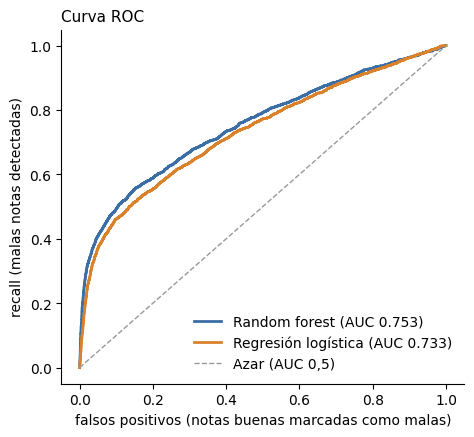

In [8]:
fig, eje = plt.subplots(figsize=(5.2, 4.6))
for prob, nombre, color in [(prob_rf, "Random forest", AZUL), (prob_log, "Regresión logística", NARANJA)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    eje.plot(fpr, tpr, color=color, linewidth=2, label=f"{nombre} (AUC {roc_auc_score(y_test, prob):.3f})")
eje.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1, label="Azar (AUC 0,5)")
eje.set_xlabel("falsos positivos (notas buenas marcadas como malas)")
eje.set_ylabel("recall (malas notas detectadas)")
eje.set_title("Curva ROC", loc="left", fontsize=11)
eje.legend(frameon=False, loc="lower right")
eje.spines[["top", "right"]].set_visible(False)
plt.show()

### El umbral es una decisión de negocio
El modelo da una probabilidad; a partir de qué valor se actúa lo decide el negocio.
Umbral bajo: se detectan más casos pero se contacta a mucha gente que no lo necesitaba.

In [9]:
filas = []
for umbral in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = prob_rf >= umbral
    filas.append({"umbral": umbral,
                  "pedidos_marcados": pred.sum(),
                  "pct_marcados": 100 * pred.mean(),
                  "precision": precision_score(y_test, pred),
                  "recall": recall_score(y_test, pred)})
pd.DataFrame(filas).set_index("umbral").round(3)

,pedidos_marcados,pct_marcados,precision,recall
umbral,,,,
0.3,10367,54.243,0.188,0.795
0.4,4819,25.215,0.300,0.590
0.5,3093,16.184,0.403,0.510
0.6,2137,11.181,0.498,0.435
0.7,1430,7.482,0.615,0.359
0.8,1062,5.557,0.701,0.304


## 5. ¿Cuánto aporta saber cómo fue la entrega?
Entrenamos el mismo random forest solo con lo que se sabe **al comprar**.

In [10]:
columnas_compra = [c for c in X.columns if c not in numericas_entrega]

bosque_compra = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, class_weight="balanced",
                                       n_jobs=-1, random_state=42)
bosque_compra.fit(X_train[columnas_compra], y_train)
prob_compra = bosque_compra.predict_proba(X_test[columnas_compra])[:, 1]

pd.DataFrame([metricas("Solo datos de la compra", prob_compra),
              metricas("Compra + entrega", prob_rf)]).set_index("modelo").round(3)

,accuracy,precision,recall,AUC
modelo,,,,
Solo datos de la compra,0.742,0.221,0.40,0.636
Compra + entrega,0.841,0.403,0.51,0.753


## 5b. Validación temporal
La partición aleatoria mezcla pedidos de todas las fechas. En la práctica el modelo se entrena con el pasado
y predice el futuro, así que repetimos la prueba de forma más exigente:
entrenar con los pedidos anteriores a mayo de 2018 y evaluar con los de mayo a agosto de 2018.

In [11]:
pasado = (datos["order_purchase_timestamp"] < "2018-05-01").values

bosque_temporal = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, class_weight="balanced",
                                         n_jobs=-1, random_state=42)
bosque_temporal.fit(X[pasado], y[pasado])
prob_temporal = bosque_temporal.predict_proba(X[~pasado])[:, 1]

print(f"Entrenamiento (hasta abr-2018): {pasado.sum():,} pedidos, {y[pasado].mean():.1%} con mala nota")
print(f"Prueba (may-ago 2018):          {(~pasado).sum():,} pedidos, {y[~pasado].mean():.1%} con mala nota")
print(f"AUC con partición aleatoria:    {roc_auc_score(y_test, prob_rf):.3f}")
print(f"AUC con partición temporal:     {roc_auc_score(y[~pasado], prob_temporal):.3f}")

Entrenamiento (hasta abr-2018): 70,318 pedidos, 13.8% con mala nota
Prueba (may-ago 2018):          25,242 pedidos, 10.0% con mala nota
AUC con partición aleatoria:    0.753
AUC con partición temporal:     0.698


## 6. Qué variables pesan más
La importancia de un random forest indica cuánto ayuda cada variable a separar los casos.
No dice en qué dirección ni que sea la causa.

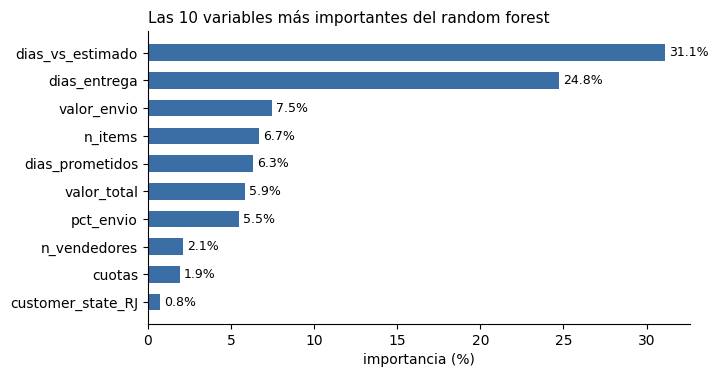

In [12]:
importancia = pd.Series(bosque.feature_importances_, index=X.columns).sort_values(ascending=False)

top = importancia.head(10).sort_values()
fig, eje = plt.subplots(figsize=(7, 3.8))
barras = eje.barh(top.index, top.values * 100, color=AZUL, height=0.6)
eje.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
eje.set_xlabel("importancia (%)")
eje.set_title("Las 10 variables más importantes del random forest", loc="left", fontsize=11)
eje.spines[["top", "right"]].set_visible(False)
plt.show()

## 7. Traducción al negocio
Ordenamos los pedidos de prueba de más a menos riesgo y miramos qué pasa si atención al cliente
solo puede contactar con una parte.

In [13]:
ranking = pd.DataFrame({"prob": prob_rf, "mala_nota": y_test.values}).sort_values("prob", ascending=False)
total_malas = ranking["mala_nota"].sum()

filas = []
for pct in [5, 10, 20, 30]:
    n = int(len(ranking) * pct / 100)
    grupo = ranking.head(n)
    filas.append({"pct_pedidos_contactados": pct,
                  "pedidos": n,
                  "malas_notas_dentro": grupo["mala_nota"].sum(),
                  "pct_de_todas_las_malas": 100 * grupo["mala_nota"].sum() / total_malas,
                  "tasa_mala_nota_en_grupo": 100 * grupo["mala_nota"].mean()})
pd.DataFrame(filas).set_index("pct_pedidos_contactados").round(1)

,pedidos,malas_notas_dentro,pct_de_todas_las_malas,tasa_mala_nota_en_grupo
pct_pedidos_contactados,,,,
5,955,690,28.2,72.3
10,1911,1018,41.6,53.3
20,3822,1352,55.3,35.4
30,5733,1539,62.9,26.8


## 8. Limitaciones
- **Cambios en el tiempo.** El apartado 5b muestra el resultado con partición temporal; si el negocio cambia (nuevos transportistas, otra política de plazos), el modelo hay que reentrenarlo.
- **Faltan variables importantes** que no están en los datos: calidad del producto, estado del paquete, atención recibida.
- **Importancia no es causalidad.** Que una variable ayude a predecir no demuestra que provoque la mala nota.
- **Hiperparámetros sin optimizar.** Se han usado valores razonables, sin búsqueda sistemática.